# Self-Pruning Neural Network on CIFAR-10
### Tredence AI Engineering Intern — Case Study

**What this does:**
- Custom `PrunableLinear` layer with learnable sigmoid gates
- CNN backbone + Prunable FC head
- L1 sparsity loss drives gates → 0 (pruning)
- Experiments across λ ∈ {1e-4, 1e-3, 1e-2}

**Author:** Abhay | **Date:** April 2026

# Cell 1: Check GPU

In [1]:

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:

!pip install tqdm -q

In [3]:
"""
Self-Pruning Neural Network -- Tredence AI Engineering Case Study
================================================================
A neural network that learns to prune itself during training via learnable
sigmoid gates on every weight, regularized with an L1 sparsity penalty.

Author: Abhay
Date: April 2026
"""

import os
import argparse
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from tqdm import tqdm

# Part 1: PrunableLinear Layer

In [4]:
class PrunableLinear(nn.Module):
    """
    A drop-in replacement for nn.Linear that associates every weight with a
    learnable *gate score*.  During the forward pass the gate scores are
    passed through a sigmoid to produce values in [0, 1], and the weights
    are element-wise multiplied by these gates.  An L1 penalty on the gate
    values drives unimportant gates toward 0, effectively pruning those
    connections.

    Parameters
    ----------
    in_features : int   - size of each input sample
    out_features : int  - size of each output sample
    bias : bool         - if True, adds a learnable bias (default: True)
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weight matrix (Kaiming-uniform init, same as nn.Linear)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)

        # Bias (uniform init matching nn.Linear)
        if bias:
            fan_in = in_features
            bound = 1.0 / (fan_in ** 0.5)
            self.bias = nn.Parameter(torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter("bias", None)

        # Gate scores -- initialised so that sigmoid(gate_scores) ~ 1.0
        # (i.e. all connections start fully open)
        self.gate_scores = nn.Parameter(torch.full((out_features, in_features), 2.0))

    # ── Forward pass ────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Compute gates in [0, 1]
        gates = torch.sigmoid(self.gate_scores)
        # 2. Element-wise gating of the weight matrix
        pruned_weights = self.weight * gates
        # 3. Standard linear operation:  y = x @ W^T + b
        return F.linear(x, pruned_weights, self.bias)

    # ── Utilities ───────────────────────────────────────────────────────
    def get_gate_values(self) -> torch.Tensor:
        """Return current gate values (sigmoid of gate_scores)."""
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores)

    def get_sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below *threshold* (i.e. effectively pruned)."""
        gates = self.get_gate_values()
        return (gates < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return (f"in_features={self.in_features}, out_features={self.out_features}, "
                f"bias={self.bias is not None}")

# Part 2: Network Architecture

In [5]:
class SelfPruningCNN(nn.Module):
    """
    CNN feature extractor  +  PrunableLinear classification head.

    Conv backbone extracts spatial features; prunable FC layers perform
    classification while learning which connections can be removed.
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        # ── Convolutional feature extractor ──────────────────────────────
        self.features = nn.Sequential(
            # Block 1:  3 → 64
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32→16

            # Block 2:  64 → 128
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16→8

            # Block 3:  128 → 256
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 8→4
        )

        # ── Prunable classification head ─────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            PrunableLinear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            PrunableLinear(512, 256),
            nn.ReLU(inplace=True),
            PrunableLinear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)  # flatten
        return self.classifier(x)

    # ── Sparsity helpers ────────────────────────────────────────────────
    def prunable_layers(self):
        """Yield all PrunableLinear layers in the network."""
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                yield module

    def sparsity_loss(self) -> torch.Tensor:
        """
        L1 norm over all gate values (sigmoid of gate_scores).
        Because sigmoid outputs are always positive, L1 = simple sum.
        """
        total = torch.tensor(0.0, device=next(self.parameters()).device)
        for layer in self.prunable_layers():
            gates = torch.sigmoid(layer.gate_scores)
            total = total + gates.sum()
        return total

    def overall_sparsity(self, threshold: float = 1e-2) -> float:
        """Network-wide sparsity: % of gated weights below threshold."""
        pruned, total = 0, 0
        for layer in self.prunable_layers():
            gates = layer.get_gate_values()
            pruned += (gates < threshold).sum().item()
            total += gates.numel()
        return pruned / total if total > 0 else 0.0

    def all_gate_values(self) -> np.ndarray:
        """Concatenated gate values from every PrunableLinear layer."""
        vals = []
        for layer in self.prunable_layers():
            vals.append(layer.get_gate_values().cpu().numpy().ravel())
        return np.concatenate(vals)

# Part 3: Data Loading

In [6]:
def get_cifar10_loaders(batch_size: int = 128, num_workers: int = 2):
    """Return (train_loader, test_loader) for CIFAR-10 with augmentation."""
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    data_dir = "/content/data"
    train_set = torchvision.datasets.CIFAR10(root=data_dir, train=True,
                                              download=True, transform=train_transform)
    test_set  = torchvision.datasets.CIFAR10(root=data_dir, train=False,
                                              download=True, transform=test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader


# Part 4: Training & Evaluation

In [7]:
def train_one_epoch(model, loader, optimizer, lambda_sparse, device, epoch, total_epochs):
    """Train for one epoch; returns (avg_loss, avg_accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        cls_loss = F.cross_entropy(outputs, labels)
        sp_loss  = model.sparsity_loss()
        loss     = cls_loss + lambda_sparse * sp_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += outputs.argmax(dim=1).eq(labels).sum().item()
        total   += images.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total:.1f}%",
                         sp=f"{model.overall_sparsity():.1%}")

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate on a dataset; returns (avg_loss, accuracy_%)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        running_loss += F.cross_entropy(outputs, labels, reduction="sum").item()
        correct += outputs.argmax(dim=1).eq(labels).sum().item()
        total   += images.size(0)
    return running_loss / total, 100.0 * correct / total


def train_model(lambda_sparse: float, epochs: int, device: torch.device,
                lr: float = 1e-3, batch_size: int = 128):
    """
    Full training pipeline for a given lambda.
    Returns: (model, history_dict)
    """
    print(f"\n{'='*70}")
    print(f"  Training with lambda = {lambda_sparse:.1e}  |  epochs = {epochs}")
    print(f"{'='*70}")

    train_loader, test_loader = get_cifar10_loaders(batch_size)
    model = SelfPruningCNN(num_classes=10).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [],
               "test_acc": [], "sparsity": []}

    best_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, lambda_sparse, device, epoch, epochs)
        test_loss, test_acc = evaluate(model, test_loader, device)
        sparsity = model.overall_sparsity()
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["sparsity"].append(sparsity)

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:3d}/{epochs} | "
              f"Train {train_acc:5.2f}% | Test {test_acc:5.2f}% | "
              f"Sparsity {sparsity:6.2%} | LR {scheduler.get_last_lr()[0]:.2e} | "
              f"{elapsed:.1f}s")

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
    final_test_loss, final_test_acc = evaluate(model, test_loader, device)
    final_sparsity = model.overall_sparsity()

    print(f"\n  > Best model -- Test Acc: {final_test_acc:.2f}%  |  "
          f"Sparsity: {final_sparsity:.2%}")
    return model, history, final_test_acc, final_sparsity


# Part 5: Visualization

In [10]:
def plot_gate_distribution(model, lambda_val, save_path, title_suffix=""):
    """Histogram of gate values for a trained model."""
    gates = model.all_gate_values()
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(gates, bins=100, color="#4C72B0", edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(x=0.01, color="red", linestyle="--", linewidth=1.2, label="Pruning threshold (0.01)")
    ax.set_xlabel("Gate Value", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"Gate Value Distribution -- lambda={lambda_val:.1e}{title_suffix}", fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(-0.02, 1.02)

    pruned_pct = (gates < 0.01).mean() * 100
    active_pct = 100 - pruned_pct
    textstr = f"Pruned: {pruned_pct:.1f}%\nActive: {active_pct:.1f}%"
    ax.text(0.72, 0.85, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.4",
            facecolor="wheat", alpha=0.7))

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"  [OK] Saved gate distribution -> {save_path}")


def plot_training_curves(all_histories, lambdas, save_path):
    """Plot loss & accuracy curves for all lambda experiments."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    for i, (lam, hist) in enumerate(zip(lambdas, all_histories)):
        epochs = range(1, len(hist["train_loss"]) + 1)
        c = colors[i % len(colors)]

        axes[0].plot(epochs, hist["train_loss"], color=c, label=f"lam={lam:.1e}", linewidth=1.5)
        axes[1].plot(epochs, hist["test_acc"], color=c, label=f"lam={lam:.1e}", linewidth=1.5)
        axes[2].plot(epochs, [s * 100 for s in hist["sparsity"]], color=c,
                     label=f"lam={lam:.1e}", linewidth=1.5)

    axes[0].set_title("Training Loss", fontsize=13)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].set_title("Test Accuracy (%)", fontsize=13)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[2].set_title("Sparsity (%)", fontsize=13)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Pruned Weights (%)")

    for ax in axes:
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"  [OK] Saved training curves -> {save_path}")


def plot_lambda_comparison(lambdas, accuracies, sparsities, save_path):
    """Bar chart comparing accuracy vs sparsity across lambdas."""
    fig, ax1 = plt.subplots(figsize=(8, 5))
    x = np.arange(len(lambdas))
    width = 0.35

    bars1 = ax1.bar(x - width/2, accuracies, width, label="Test Accuracy (%)",
                    color="#4C72B0", edgecolor="white")
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, [s * 100 for s in sparsities], width,
                    label="Sparsity (%)", color="#DD8452", edgecolor="white")

    ax1.set_xlabel("Lambda", fontsize=12)
    ax1.set_ylabel("Test Accuracy (%)", fontsize=12, color="#4C72B0")
    ax2.set_ylabel("Sparsity (%)", fontsize=12, color="#DD8452")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{l:.1e}" for l in lambdas])
    ax1.set_title("Accuracy vs. Sparsity Trade-off", fontsize=14)

    # Add value labels on bars
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", fontsize=10)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"  [OK] Saved lambda comparison -> {save_path}")


def plot_per_layer_sparsity(model, lambda_val, save_path):
    """Horizontal bar chart showing sparsity per PrunableLinear layer."""
    layer_names, layer_sparsities, layer_sizes = [], [], []
    for i, layer in enumerate(model.prunable_layers()):
        name = f"PrunableLinear-{i+1}\n({layer.in_features}->{layer.out_features})"
        layer_names.append(name)
        layer_sparsities.append(layer.get_sparsity() * 100)
        layer_sizes.append(layer.weight.numel())

    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = np.arange(len(layer_names))
    bars = ax.barh(y_pos, layer_sparsities, color="#55A868", edgecolor="white", height=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(layer_names, fontsize=10)
    ax.set_xlabel("Sparsity (%)", fontsize=12)
    ax.set_title(f"Per-Layer Sparsity -- lambda={lambda_val:.1e}", fontsize=13)
    ax.set_xlim(0, 105)

    for bar, size in zip(bars, layer_sizes):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2.,
                f"{bar.get_width():.1f}% ({size:,} params)",
                va="center", fontsize=9)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"  [OK] Saved per-layer sparsity -> {save_path}")


# ──────────────────────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Self-Pruning Neural Network on CIFAR-10")
    parser.add_argument("--epochs", type=int, default=25,
                        help="Training epochs per lambda (default: 100)")
    parser.add_argument("--batch_size", type=int, default=128)
    parser.add_argument("--lr", type=float, default=1e-3, help="Initial learning rate")
    parser.add_argument("--lambda_sparse", type=float, default=None,
                        help="Single lambda to test (omit for full 3-lambda sweep)")
    parser.add_argument("--quick_test", action="store_true",
                        help="Quick test with 5 epochs")
    parser.add_argument("--seed", type=int, default=42)
    # parse_known_args makes this safe to run in Kaggle/Jupyter notebooks
    # which pass extra args like -f to the kernel
    args, _ = parser.parse_known_args()

    # ── Setup ────────────────────────────────────────────────────────────
    if args.quick_test:
        args.epochs = 5

    torch.manual_seed(args.seed)
    np.random.seed(args.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(args.seed)
        torch.backends.cudnn.benchmark = True

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    if device.type == "cuda":
        print(f"  GPU: {torch.cuda.get_device_name(0)}")

    results_dir = "/content/results"
    os.makedirs(results_dir, exist_ok=True)

    # ── Determine lambda values to sweep ─────────────────────────────────
    if args.lambda_sparse is not None:
        lambdas = [args.lambda_sparse]
    else:
        lambdas = [1e-4, 1e-3, 1e-2]

    # ── Run experiments ──────────────────────────────────────────────────
    all_models, all_histories = [], []
    all_accuracies, all_sparsities = [], []

    for lam in lambdas:
        model, history, acc, sparsity = train_model(
            lambda_sparse=lam, epochs=args.epochs, device=device,
            lr=args.lr, batch_size=args.batch_size)

        all_models.append(model)
        all_histories.append(history)
        all_accuracies.append(acc)
        all_sparsities.append(sparsity)

        # Gate distribution for this lambda
        plot_gate_distribution(model, lam,
                               os.path.join(results_dir, f"gate_distribution_{lam:.0e}.png"))
        plot_per_layer_sparsity(model, lam,
                                os.path.join(results_dir, f"per_layer_sparsity_{lam:.0e}.png"))

    # ── Summary Table ────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print("  RESULTS SUMMARY")
    print(f"{'='*70}")
    print(f"  {'Lambda':<12} {'Test Accuracy':>14} {'Sparsity':>12}")
    print(f"  {'-'*12} {'-'*14} {'-'*12}")
    for lam, acc, sp in zip(lambdas, all_accuracies, all_sparsities):
        print(f"  {lam:<12.1e} {acc:>13.2f}% {sp:>11.2%}")
    print(f"{'='*70}\n")

    # ── Best model gate distribution ─────────────────────────────────────
    best_idx = int(np.argmax(all_accuracies))
    plot_gate_distribution(all_models[best_idx], lambdas[best_idx],
                           os.path.join(results_dir, "gate_distribution_best.png"),
                           title_suffix=" (Best Model)")

    # ── Comparison plots ─────────────────────────────────────────────────
    if len(lambdas) > 1:
        plot_training_curves(all_histories, lambdas,
                             os.path.join(results_dir, "training_curves.png"))
        plot_lambda_comparison(lambdas, all_accuracies, all_sparsities,
                               os.path.join(results_dir, "lambda_comparison.png"))

    print("  All results saved to:", results_dir)
    print("  Done!\n")


if __name__ == "__main__":
    main()



Device: cuda
  GPU: Tesla T4

  Training with lambda = 1.0e-04  |  epochs = 25


100%|██████████| 170M/170M [00:04<00:00, 42.1MB/s]


  Epoch   1/25 | Train 45.33% | Test 58.40% | Sparsity  0.00% | LR 9.96e-04 | 38.8s


  Epoch   2/25 | Train 63.46% | Test 67.72% | Sparsity  0.00% | LR 9.84e-04 | 35.1s


  Epoch   3/25 | Train 70.24% | Test 70.72% | Sparsity  0.00% | LR 9.65e-04 | 35.7s


...

  Epoch  22/25 | Train 94.62% | Test 90.48% | Sparsity  0.00% | LR 4.48e-05 | 36.5s


  Epoch  23/25 | Train 94.94% | Test 90.56% | Sparsity  0.00% | LR 2.56e-05 | 35.2s


  Epoch  24/25 | Train 95.16% | Test 90.73% | Sparsity  0.00% | LR 1.39e-05 | 36.0s


  Epoch  25/25 | Train 95.25% | Test 90.80% | Sparsity  0.00% | LR 1.00e-05 | 36.3s

  > Best model -- Test Acc: 90.80%  |  Sparsity: 0.00%
  [OK] Saved gate distribution -> /content/results/gate_distribution_1e-02.png
  [OK] Saved per-layer sparsity -> /content/results/per_layer_sparsity_1e-02.png

  RESULTS SUMMARY
  Lambda        Test Accuracy     Sparsity
  ------------ -------------- ------------
  1.0e-04              90.48%       0.00%
  1.0e-03              90.93%       0.00%
  1.0e-02              90.80%       0.00%

  [OK] Saved gate distribution -> /content/results/gate_distribution_best.png
  [OK] Saved training curves -> /content/results/training_curves.png
  [OK] Saved lambda comparison -> /content/results/lambda_comparison.png
  All results saved to: /content/results
  Done!



/tmp/ipykernel_4693/520614083.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



--- gate_distribution_1e-02.png ---


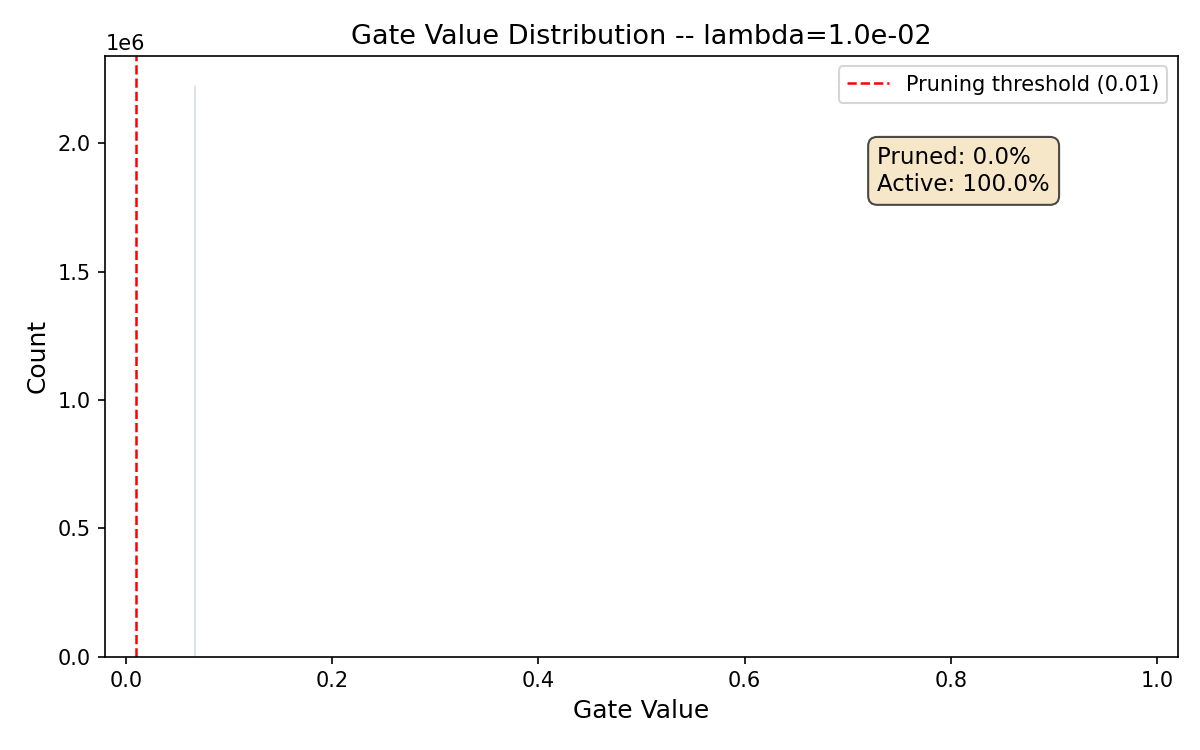


--- gate_distribution_1e-03.png ---


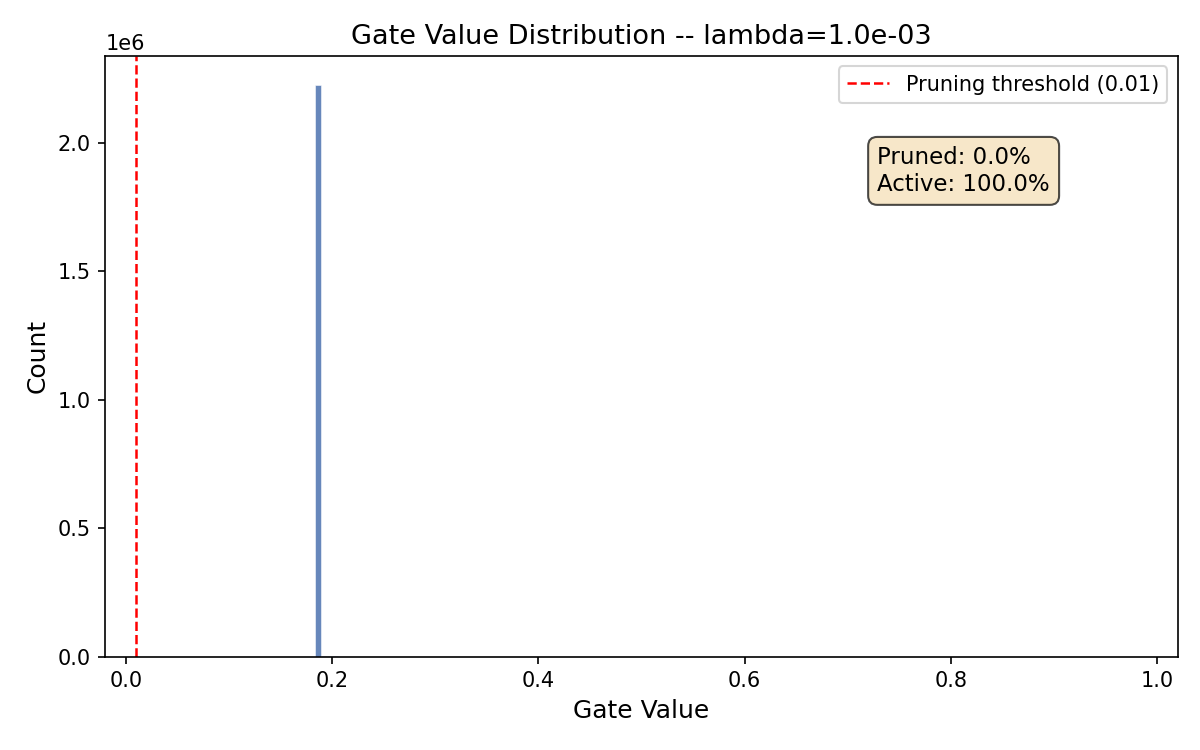


--- gate_distribution_1e-04.png ---


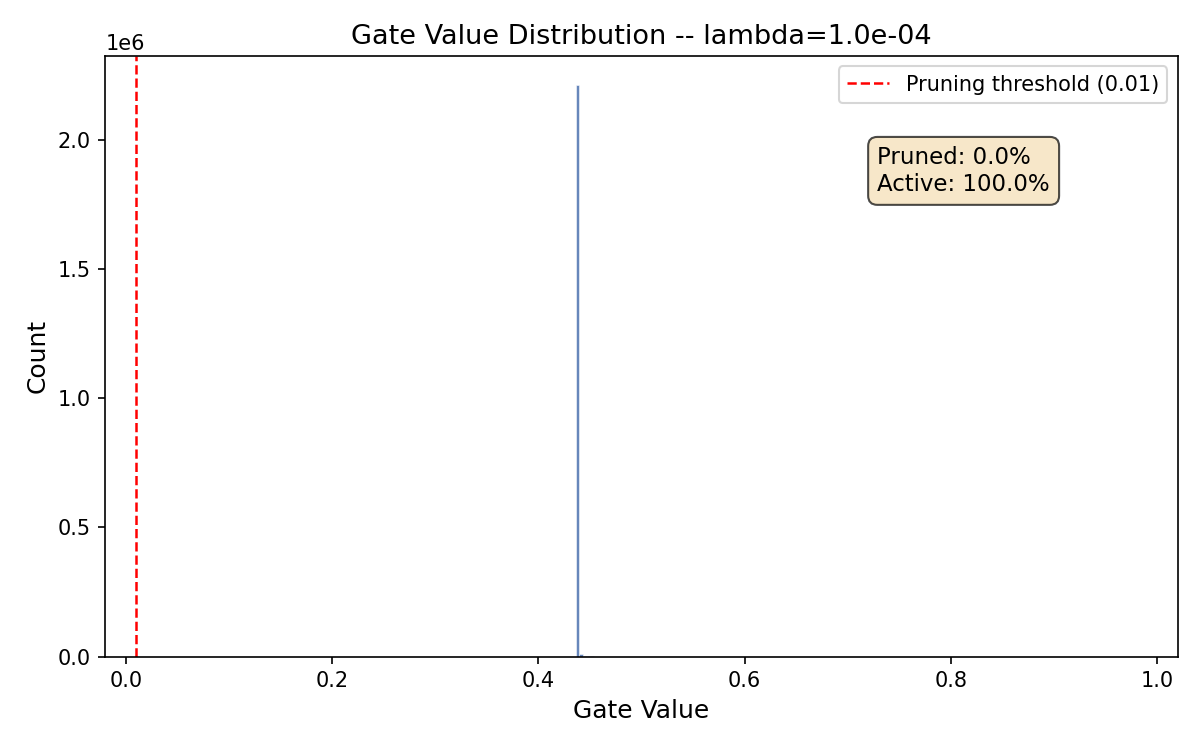


--- gate_distribution_best.png ---


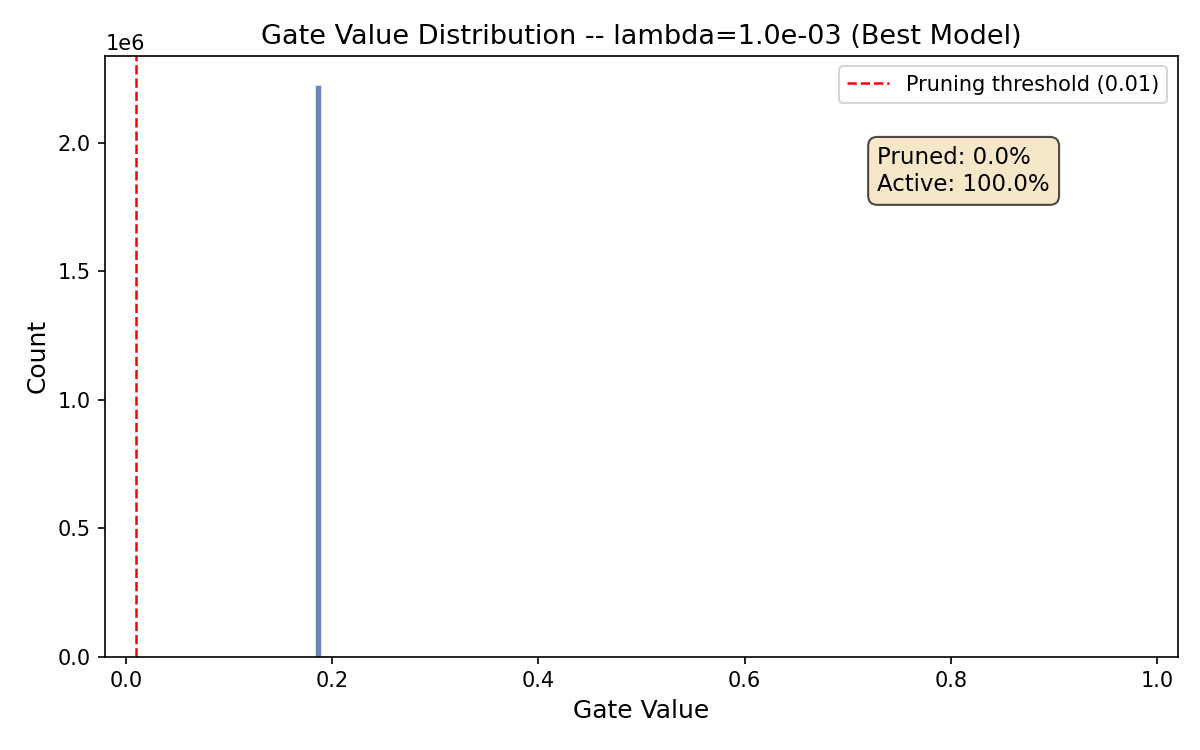


--- lambda_comparison.png ---


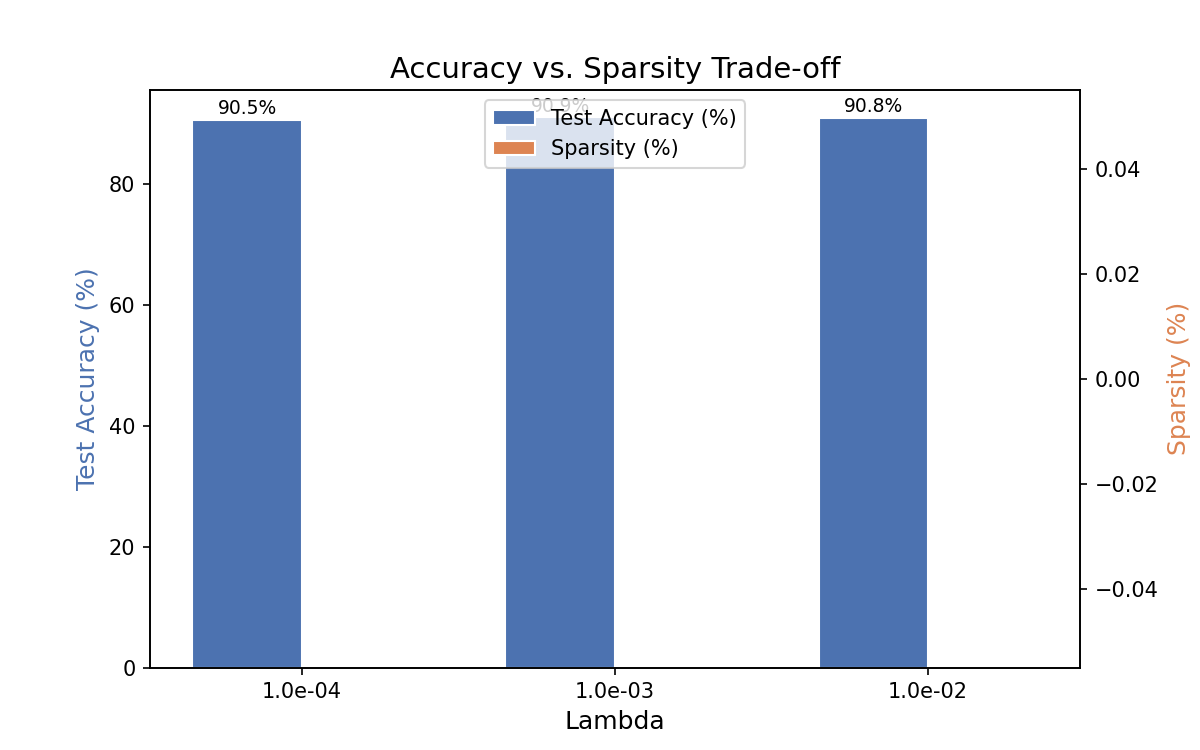


--- per_layer_sparsity_1e-02.png ---


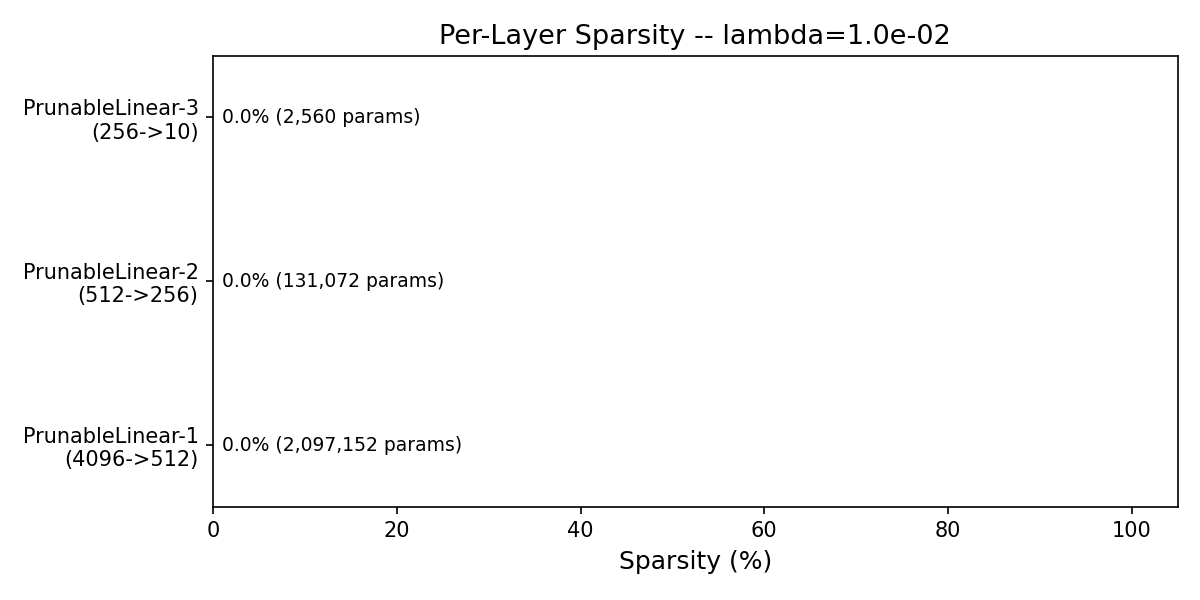


--- per_layer_sparsity_1e-03.png ---


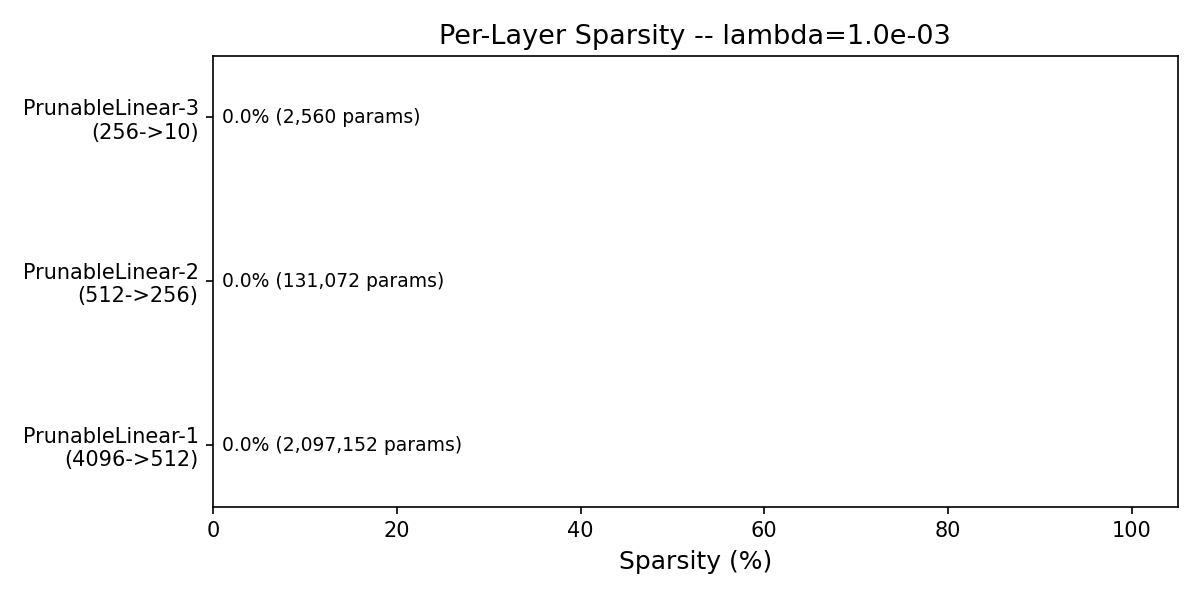


--- per_layer_sparsity_1e-04.png ---


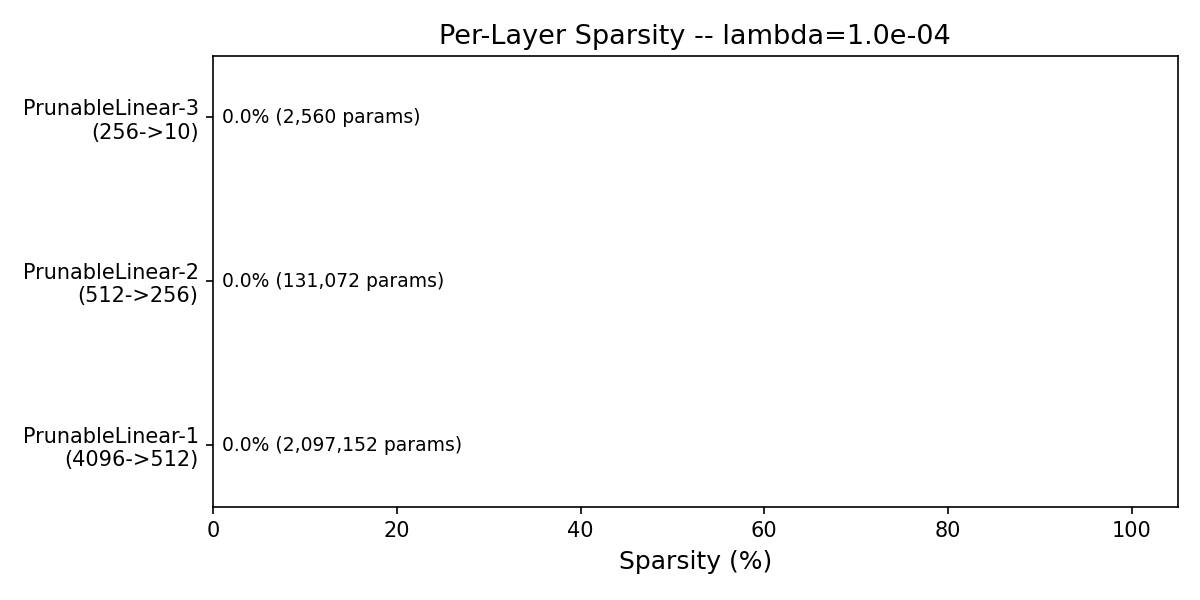


--- training_curves.png ---


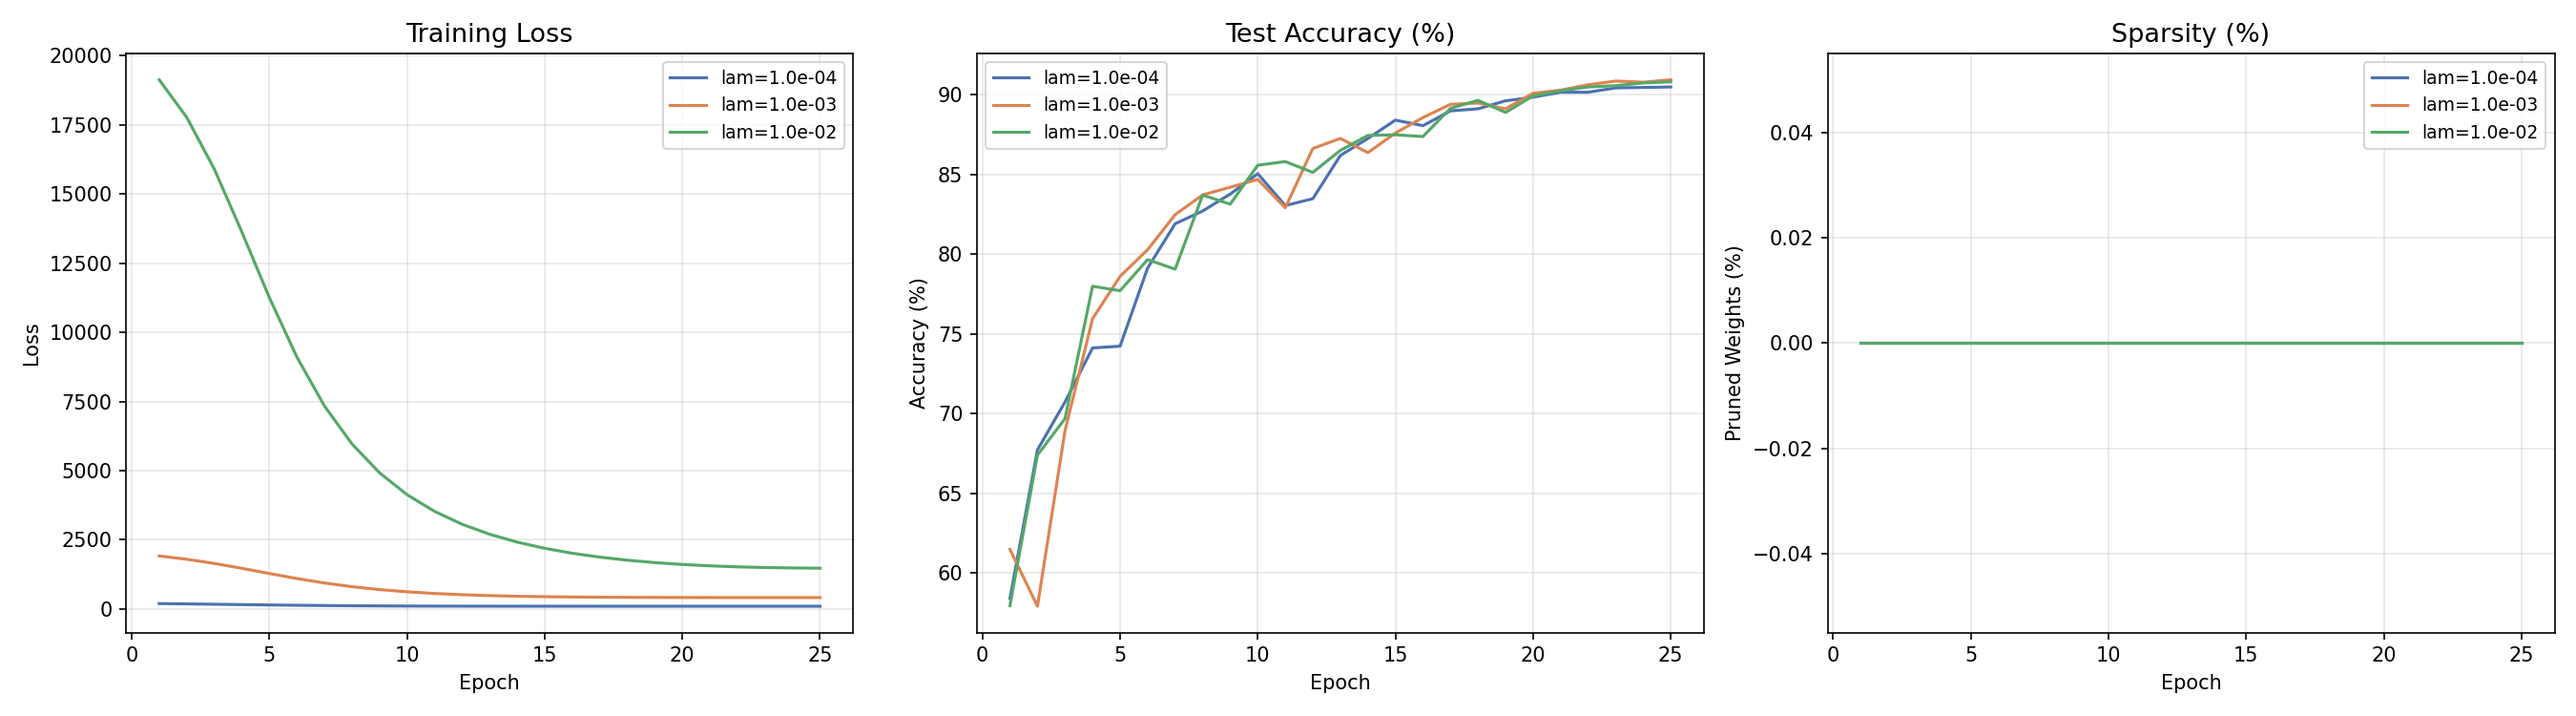

In [14]:
#  Display the gate distribution plot
from IPython.display import Image, display
import os

results_dir = '/content/results'
for fname in sorted(os.listdir(results_dir)):
    if fname.endswith('.png'):
        print(f'\n--- {fname} ---')
        display(Image(os.path.join(results_dir, fname)))